# Задание

Основные метрики:
* Время за сессию
* Время на юзера
* Доля «непрослушанных» треков

Провести EDA, выяснить, что в большей степени влияет на указанные метрики.
Насколько перспективным было бы использовать CUPED (сильно ли коррелирует текущая история метрики с ее предысторией?).

In [35]:
import pandas as pd

df = pd.read_parquet("zvuk-interactions.parquet", engine="fastparquet")

# семплируем данные
df = df.sample(frac=0.01, random_state=42)

In [37]:
df = df.dropna()

df = df.astype({
    "session_id": "int64",
    "user_id": "int64",
    "track_id": "int64",
    "play_duration": "float64"
})

df['datetime'] = pd.to_datetime(df['datetime'])
df.head()

,user_id,session_id,datetime,track_id,play_duration
61355373,9395417,6624337,2023-03-19 03:07:36.517,1494938,94.000000
63451678,4067710,2080247,2023-05-06 10:03:39.468,1017238,4.999992
175277420,1940895,10969639,2023-04-21 04:46:10.901,414402,52.000000
119370813,2978598,10954583,2023-03-07 07:47:43.190,412548,199.000000
47555552,6869336,837825,2023-04-07 02:46:27.078,697662,-0.000008


1. Посчитаем время за сессию: вычитая max(datetime) - min(datetime) by session_id
2. Посчитаем среднее время на юзера, как сумму всех времён по user_id
3. Посчитаем долю непрослушанных треков по юзеру,
4. Выясним, что в большей степени влияет на указанные метрики

In [44]:
session_time = (
    df.groupby('session_id')['datetime']
    .agg(['min', 'max'])
    .assign(session_time=lambda x: (x['max'] - x['min']).dt.total_seconds())
    .reset_index()
)
# удалим выбросы
user_time = (
    df.merge(session_time, on='session_id')
    .groupby('user_id')['session_time']
    .sum()
    .reset_index(name='user_time')
)


df['unplayed'] = df['play_duration'] < 30

user_unplayed_share = (
    df.groupby('user_id')['unplayed']
    .mean()
    .reset_index(name='unplayed_share')
)

metrics = (
    user_time
    .merge(user_unplayed_share, on='user_id', how='left')
)


,session_id,min,max,session_time
0,8,2023-02-17 11:45:55.054,2023-02-17 11:45:55.054,0.000
1,13,2023-04-07 08:12:48.515,2023-04-07 08:12:48.515,0.000
2,15,2023-02-15 06:46:57.320,2023-02-15 06:46:57.320,0.000
3,17,2023-04-29 23:26:31.296,2023-04-29 23:26:31.296,0.000
4,19,2023-01-20 08:22:45.518,2023-01-20 08:22:45.518,0.000
...,...,...,...,...
1831603,13027720,2023-04-07 12:04:17.656,2023-04-07 12:04:17.656,0.000
1831604,13027722,2023-01-24 00:28:13.434,2023-01-24 00:28:13.610,0.176
1831605,13027739,2023-01-18 03:07:58.664,2023-01-18 03:07:58.664,0.000
1831606,13027746,2023-04-01 08:50:16.017,2023-04-01 08:50:16.017,0.000


In [51]:
session_durations = (
    df.groupby('session_id')['datetime']
    .agg(['min', 'max'])
    .assign(session_time=lambda x: (x['max'] - x['min']).dt.total_seconds())
    .reset_index()
)

# Присоединим к каждой сессии пользователя
user_session_durations = df[['user_id', 'session_id']].drop_duplicates()
user_session_durations = user_session_durations.merge(session_durations, on='session_id', how='left')

# Время на пользователя = сумма всех времен сессий пользователя
user_total_time = (
    user_session_durations.groupby('user_id')['session_time']
    .sum()
    .reset_index(name='user_total_time')
)

# Доля непрослушанных треков
df['is_unplayed'] = df['play_duration'] < 30

user_unplayed_ratio = (
    df.groupby('user_id')['is_unplayed']
    .mean()
    .reset_index(name='unplayed_ratio')
)

In [52]:
user_metrics = (
    user_total_time
    .merge(user_unplayed_ratio, on='user_id', how='left')
)

user_metrics.describe()

,user_id,user_total_time,unplayed_ratio
count,2.394400e+05,2.394400e+05,239440.000000
mean,5.496757e+06,1.368834e+06,0.424553
std,2.593754e+06,3.483650e+06,0.353355
min,1.000077e+06,0.000000e+00,0.000000
25%,3.249209e+06,0.000000e+00,0.066667
50%,5.497160e+06,5.998300e+01,0.384615
75%,7.742091e+06,9.453083e+03,0.666667
max,9.999982e+06,2.032303e+07,1.000000


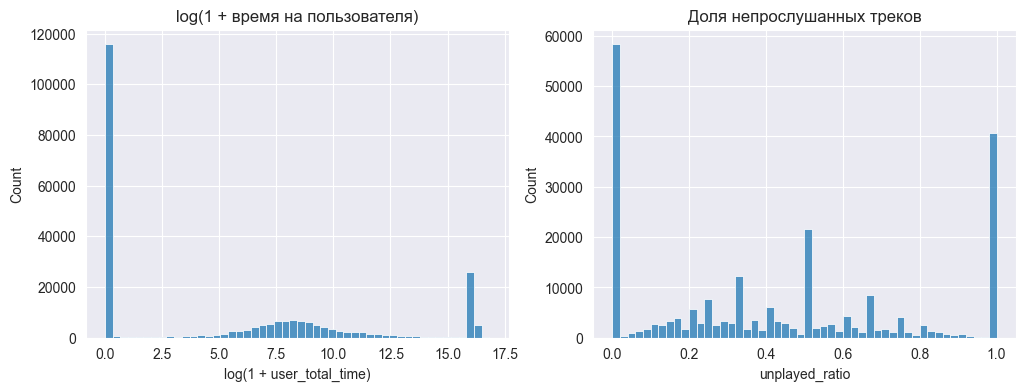

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(np.log1p(user_metrics['user_total_time']), bins=50, ax=axes[0])
axes[0].set_title('log(1 + время на пользователя)')
axes[0].set_xlabel('log(1 + user_total_time)')

sns.histplot(user_metrics['unplayed_ratio'], bins=50, ax=axes[1])
axes[1].set_title('Доля непрослушанных треков')
plt.show()

In [76]:
user_metrics['user_total_time']

0         4.697908e+03
1         3.906820e+02
2         0.000000e+00
3         0.000000e+00
4         3.866037e+03
              ...     
239435    1.035605e+07
239436    3.126575e+03
239437    9.610000e-01
239438    0.000000e+00
239439    0.000000e+00
Name: user_total_time, Length: 239440, dtype: float64

Проверим гипотезы:
- H1: пользователи с большей вовлечённостью (user_time) слушают треки дольше
- H2: доля непрослушанных треков отрицательно коррелирует с user_time
- H3: внутри одной сессии unplayed_ration имеет меньший разброс, чем внутри разных сессий у пользователя

## H1: пользователи с большей вовлечённостью (user_time) слушают треки дольше

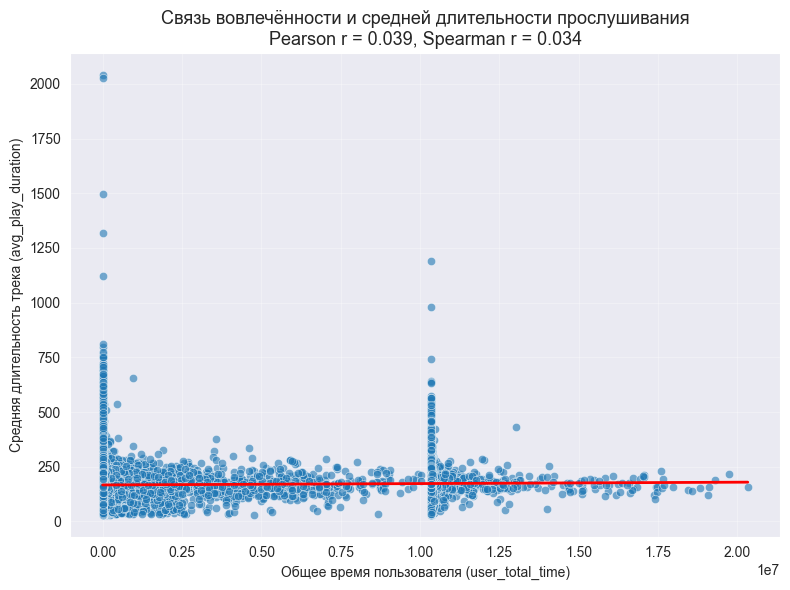

In [72]:
from scipy.stats import pearsonr, spearmanr

# Убираем непрослушанные треки
df_filtered = df[df['is_unplayed'] == False].copy()

user_avg_play = (
    df_filtered.groupby('user_id')['play_duration']
    .mean()
    .reset_index(name='avg_play_duration')
)

user_check = (
    user_metrics
    .merge(user_avg_play, on='user_id', how='left')
    .dropna()
)

pearson_r, pearson_p = pearsonr(user_check['user_total_time'], user_check['avg_play_duration'])
spearman_r, spearman_p = spearmanr(user_check['user_total_time'], user_check['avg_play_duration'])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=user_check,
    x='user_total_time',
    y='avg_play_duration',
    alpha=0.6
)

sns.regplot(
    data=user_check,
    x='user_total_time',
    y='avg_play_duration',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)

plt.title(f"Связь вовлечённости и средней длительности прослушивания\n"
          f"Pearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}",
          fontsize=13)

plt.xlabel("Общее время пользователя (user_total_time)")
plt.ylabel("Средняя длительность трека (avg_play_duration)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Так как r ≈ 0 → связи нет

Как видно, средняя продолжительность трека не меняется в завиисмости от времени пользователя.

Единственно на что можно обратить внимание - наибольший разброс в средней длительности треков в районе общего времени пользователя

## H2: доля непрослушанных треков отрицательно коррелирует с user_time

In [79]:
pearson_r, pearson_p = pearsonr(user_metrics['user_total_time'], user_metrics['unplayed_ratio'])
spearman_r, spearman_p = spearmanr(user_metrics['user_total_time'], user_metrics['unplayed_ratio'])

print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3f}")
print(f"Spearman r={spearman_r:.3f}, p={spearman_p:.3f}")


Pearson r=-0.087, p=0.000
Spearman r=-0.000, p=0.957


Как можно видеть, эффект очень слабый, поэтому гипотеза неверна.

# H3: Межсессионная дисперсия unplayed_ration больше, чем внутрисессионная unplayed_ration


Пользователей в анализе: 15541
Медиана межсессионной дисперсии: 0.00821
Медиана внутрисессионной дисперсии: 0.00751
Wilcoxon (between > within): stat=825990.000, p=2.810e-66


/Users/iopogiba/Documents/HSE/Module 1/Data Analysis Tools/PyCharmMiscProject/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/iopogiba/Documents/HSE/Module 1/Data Analysis Tools/PyCharmMiscProject/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


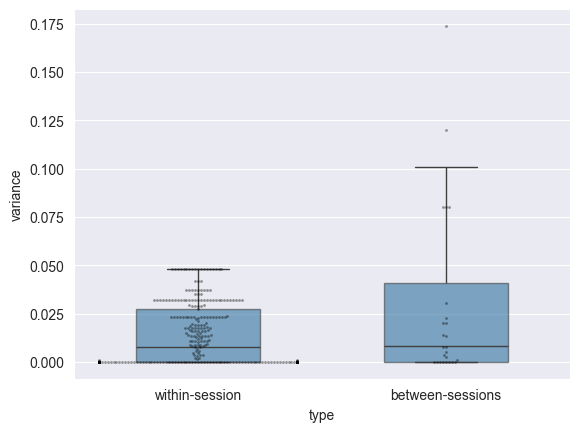

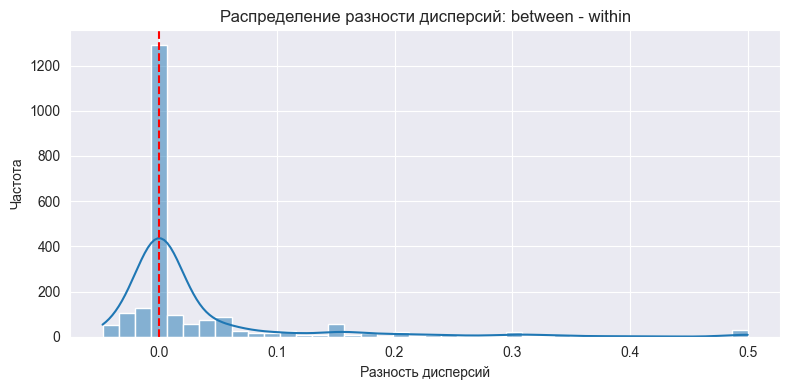

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

session_stats = (
    df.groupby(['user_id', 'session_id'])
      .agg(
          n_tracks=('track_id', 'size'),
          unplayed_ratio=('is_unplayed', 'mean')
      )
      .reset_index()
)

# Отфильтруем короткие сессии
session_stats = session_stats[session_stats['n_tracks'] >= 5]

# 3) Для каждого пользователя:
#    - межсессионная дисперсия = Var(unplayed_ratio по сессиям)
#    - внутрисессионная дисперсия (оценка) = средняя по сессиям p*(1-p)/n
session_stats['within_var_est'] = (
    session_stats['unplayed_ratio'] * (1 - session_stats['unplayed_ratio']) / session_stats['n_tracks']
)

user_var = (
    session_stats
      .groupby('user_id')
      .agg(
          between_var=('unplayed_ratio', 'var'),
          within_var=('within_var_est', 'mean'),
          n_sessions=('session_id', 'nunique')
      )
      .reset_index()
)

user_var_clean = user_var.dropna(subset=['within_var', 'between_var']).copy()
user_var_clean = user_var_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=['within_var', 'between_var'])

# 4) Статистический парный тест: H3 — within_var < between_var
stat, p_value = wilcoxon(user_var_clean['between_var'], user_var_clean['within_var'], alternative='greater')

print(f"Пользователей в анализе: {len(user_var)}")
print(f"Медиана межсессионной дисперсии: {user_var['between_var'].median():.5f}")
print(f"Медиана внутрисессионной дисперсии: {user_var['within_var'].median():.5f}")
print(f"Wilcoxon (between > within): stat={stat:.3f}, p={p_value:.3e}")

# 5) Визуализация
plot_df = (
    user_var.melt(
        id_vars='user_id',
        value_vars=['within_var', 'between_var'],
        var_name='type',
        value_name='variance'
    )
    .replace({'within_var': 'within-session', 'between_var': 'between-sessions'})
)

sns.boxplot(
    data=plot_df,
    x='type',
    y='variance',
    showfliers=False,
    width=0.5,
    boxprops={'alpha':0.6}
)
sns.swarmplot(
    data=plot_df.sample(n=500, random_state=42),  # чтобы не перегружать график
    x='type',
    y='variance',
    size=2,
    color='k',
    alpha=0.4
)


# 5.3 Распределение разности (between - within)
diff = user_var['between_var'] - user_var['within_var']
plt.figure(figsize=(8, 4))
sns.histplot(diff, bins=40, kde=True)
plt.axvline(0, color='red', ls='--')
plt.title('Распределение разности дисперсий: between - within')
plt.xlabel('Разность дисперсий')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Разброс `unplayed_ratio` внутри одной сессии существенно ниже, чем между сессиями пользователя (p < 1e-60).
Это говорит о том, что поведение в рамках одной сессии устойчиво и может использоваться для построения поведенческих сегментов или моделей предсказания.

# Проверка использования CUPED

In [91]:
# Для CUPED важно, чтобы метрика текущего периода коррелировала с прошлым
# Разделим данные по времени, например, по неделям
df['week'] = df['datetime'].dt.isocalendar().week

weekly = (
    df.groupby(['user_id', 'week'])['play_duration']
    .sum()
    .reset_index()
    .sort_values(['user_id', 'week'])
)

weekly['prev_play_duration'] = weekly.groupby('user_id')['play_duration'].shift(1)

corr_cuped = weekly[['play_duration', 'prev_play_duration']].corr().iloc[0,1]
print(f"Корреляция между текущей и прошлой неделей: {corr_cuped:.3f}")

Корреляция между текущей и прошлой неделей: 0.341


CUPED может дать умеренный выигрыш